# Fraud Detection System
### Google Colab Notebook · Multi-CSV BankSim edition

Handles one or multiple BankSim CSV files, merges them, preprocesses,
trains XGBoost, LightGBM, and MLP, and shows full metrics + comparison plots.

**BankSim files available on Kaggle:**

| File | Rows | Description |
|---|---|---|
| `bs140513_032310.csv` | ~594 k | Main simulation (6 months) |
| `bs160708_032310.csv` | ~9 k | Second simulation run |

Both have identical schemas — 10 columns with apostrophe-wrapped string values.

---

### Notebook cell map

| # | Content |
|---|---|
| 1 | Install dependencies |
| 2 | `ModelOutput` — shared DTO |
| 3 | `BaseModel` — abstract contract |
| 4 | `BaseDataProcessor` — multi-file abstract contract |
| 5 | `BaseMetricsEvaluator` — abstract contract |
| 6 | `BankSimDataProcessor` — load · merge · preprocess |
| 7 | `MetricsEvaluator` — ROC · PR · Confusion matrix · SHAP |
| 8 | `XGBoostModel` — 7 private training steps |
| 9 | `ExperimentPipeline` — orchestrator |
| 10 | **Run XGBoost** — load → train → metrics → plots |
| 11 | `LightGBMModel` — 7 private training steps |
| 12 | XGBoost vs LightGBM comparison |
| 13 | `MLPModel` — PyTorch feed-forward network |
| 14 | **XGBoost vs LightGBM vs MLP** — three-way comparison |


## Cell 1 — Dependency Installation

Run once per Colab session. `optuna` and `shap` are optional — missing packages
are handled gracefully with a warning rather than a crash.


In [1]:
!pip install xgboost>=2.0 lightgbm>=4.0 imbalanced-learn>=0.11 optuna>=3.4 shap>=0.44 torch>=2.1 -q

import importlib
for pkg in ["xgboost","lightgbm","torch","sklearn","imblearn",
            "optuna","shap","matplotlib","seaborn","pandas","numpy"]:
    try:
        importlib.import_module(pkg)
        print(f"  ✓  {pkg}")
    except ImportError:
        print(f"  ✗  {pkg}  (optional)")


/bin/bash: /home/nordonez22/workspace/back/python-projects/neural-network-notes/assignments/.venv/bin/pip: /home/nordonez22/workspace/back/python-projects/neural-network-notes/assigment1/.venv/bin/python: bad interpreter: No such file or directory
  ✓  xgboost
  ✓  lightgbm
  ✓  sklearn
  ✓  imblearn
  ✓  optuna
  ✓  shap
  ✓  matplotlib
  ✓  seaborn
  ✓  pandas
  ✓  numpy


## Cell 2 — `ModelOutput` (Shared DTO)

The **only object** exchanged between all layers.  
Every model returns one; every evaluator receives one.

| Field | Type | Purpose |
|---|---|---|
| `y_true` | `np.ndarray` | Ground-truth labels |
| `y_pred` | `np.ndarray` | Hard predictions (threshold 0.5) |
| `y_proba` | `np.ndarray` | Continuous fraud-probability scores |
| `model_name` | `str` | Human-readable identifier |
| `experiment_tag` | `str` | `"classical"` / `"federated:FedAvg"` / `"dp:…"` |
| `metadata` | `dict` | Train time, device, params, etc. |
| `feature_names` | `list[str]` | Column names for SHAP plots |


In [2]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List
import numpy as np

@dataclass
class ModelOutput:
    y_true:         np.ndarray
    y_pred:         np.ndarray
    y_proba:        np.ndarray
    model_name:     str            = "unknown"
    experiment_tag: str            = "classical"
    metadata:       Dict[str, Any] = field(default_factory=dict)
    feature_names:  List[str]      = field(default_factory=list)

    @property
    def n_samples(self) -> int:  return len(self.y_true)
    @property
    def n_fraud(self)   -> int:  return int(self.y_true.sum())
    @property
    def fraud_rate(self)-> float: return self.n_fraud / max(self.n_samples, 1)

    def to_dict(self) -> Dict[str, Any]:
        return {
            "model_name": self.model_name, "experiment_tag": self.experiment_tag,
            "y_true": self.y_true.tolist(), "y_pred": self.y_pred.tolist(),
            "y_proba": self.y_proba.tolist(), "feature_names": self.feature_names,
            "metadata": self.metadata,
        }

print("ModelOutput ✓")


ModelOutput ✓


## Cell 3 — `BaseModel` (Abstract Contract)

Forces every ML model to implement `train()` and `predict()`.  
`_assert_fitted()` is defined once here and inherited by all subclasses.


In [3]:
import abc
from typing import Any, Dict, List, Optional
import pandas as pd

class BaseModel(abc.ABC):
    def __init__(self, random_state: int = 42, **kwargs: Any) -> None:
        self.random_state = random_state
        self._params: Dict[str, Any] = {"random_state": random_state, **kwargs}
        self._is_fitted: bool = False

    @abc.abstractmethod
    def train(self, X_train: pd.DataFrame, y_train: pd.Series,
              X_val: Optional[pd.DataFrame] = None,
              y_val: Optional[pd.Series]    = None) -> None: ...

    @abc.abstractmethod
    def predict(self, X_test: pd.DataFrame, y_test: pd.Series,
                feature_names: Optional[List[str]] = None) -> ModelOutput: ...

    def get_params(self) -> Dict[str, Any]: return dict(self._params)

    def _assert_fitted(self) -> None:
        if not self._is_fitted:
            raise RuntimeError(f"{self.__class__.__name__} not trained yet.")

    @property
    def name(self) -> str: return self.__class__.__name__

print("BaseModel ✓")


BaseModel ✓


## Cell 4 — `BaseDataProcessor` (Multi-File Abstract Contract)

**New vs previous version:** the contract now mandates two extra methods:

| Method | Signature | Responsibility |
|---|---|---|
| `load_files(paths)` | `→ List[DataFrame]` | Read each CSV, strip apostrophes |
| `merge_files(frames)` | `→ DataFrame` | Concat + validate schema + sub-sample |
| `process()` | `→ (X, y)` | Clean · encode · scale |
| `split()` | `→ 4-tuple` | Stratified split + SMOTE on train |
| `get_feature_names()` | `→ List[str]` | Column names post-encoding |
| `split_federated_clients()` | `→ List[(X,y)]` | Client shards for Phase 2 |

The `merge_files()` step is where multiple CSV files converge into one  
DataFrame before any preprocessing begins.


In [4]:
import abc
from pathlib import Path
from typing import List, Tuple, Union
import numpy as np
import pandas as pd

PathLike = Union[str, Path]

class BaseDataProcessor(abc.ABC):

    @abc.abstractmethod
    def load_files(self, paths: List[PathLike]) -> List[pd.DataFrame]:
        """Read CSVs into DataFrames, stripping BankSim apostrophes."""

    @abc.abstractmethod
    def merge_files(self, frames: List[pd.DataFrame],
                    reset_index: bool = True) -> pd.DataFrame:
        """Concatenate frames, validate schema, optionally sub-sample."""

    @abc.abstractmethod
    def process(self) -> Tuple[pd.DataFrame, pd.Series]:
        """Full preprocessing pipeline → (X, y)."""

    @abc.abstractmethod
    def split(self, X: pd.DataFrame, y: pd.Series,
              test_size: float = 0.2,
              random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame,
                                               pd.Series, pd.Series]:
        """Stratified train / test split."""

    @abc.abstractmethod
    def get_feature_names(self) -> List[str]:
        """Return feature column names after processing."""

    def split_federated_clients(self, X: pd.DataFrame, y: pd.Series,
                                 n_clients: int = 5,
                                 random_state: int = 42
                                 ) -> List[Tuple[pd.DataFrame, pd.Series]]:
        """Random non-IID partition into n_clients shards."""
        np.random.seed(random_state)
        indices = np.array_split(np.random.permutation(len(X)), n_clients)
        return [(X.iloc[i].reset_index(drop=True),
                 y.iloc[i].reset_index(drop=True)) for i in indices]

print("BaseDataProcessor ✓")


BaseDataProcessor ✓


## Cell 5 — `BaseMetricsEvaluator` (Abstract Contract)

The **only class allowed** to compute metrics, print reports, or draw plots.


In [5]:
import abc
from typing import Dict, Optional

class BaseMetricsEvaluator(abc.ABC):

    @abc.abstractmethod
    def evaluate(self, output: ModelOutput) -> Dict[str, float]: ...

    @abc.abstractmethod
    def report(self, output: ModelOutput) -> str: ...

    @abc.abstractmethod
    def plot(self, output: ModelOutput, save_path: Optional[str] = None) -> None: ...

print("BaseMetricsEvaluator ✓")


BaseMetricsEvaluator ✓


## Cell 6 — `BankSimDataProcessor` (Concrete Multi-File Loader)

Implements every abstract method from `BaseDataProcessor`.

### BankSim-specific handling

| Problem | Solution |
|---|---|
| Every cell is `'value'` (apostrophe-wrapped) | `_strip_apostrophes()` strips them on load |
| `customer` / `merchant` have ~4 k unique IDs | **Frequency encoding** — replaces ID with fraction of transactions it appears in |
| `zipcodeOri` / `zipMerchant` are near-constant | Dropped in `_drop_noise_columns()` |
| `age` has a `'U'` unknown value | Mapped to `-1`, cast to int |
| Heavy class imbalance (~1.2 % fraud) | SMOTE applied to training split only |

### Local test shortcut

Set `sample_frac=0.05` to reduce ~594 k rows to ~30 k for fast iteration:
```python
processor = BankSimDataProcessor(
    csv_paths   = ["bs140513_032310.csv"],
    sample_frac = 0.05,   # ← smoke-test mode
    use_smote   = False,  # ← faster without resampling
)
```


In [6]:
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split as _tts
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
    _SMOTE_OK = True
except ImportError:
    _SMOTE_OK = False
    warnings.warn('imbalanced-learn not installed. pip install imbalanced-learn')

_REQUIRED_COLS = ['step', 'customer', 'age', 'gender',
                  'merchant', 'category', 'amount', 'fraud']
_LABEL_COL    = 'fraud'
_DROP_COLS    = ['zipcodeOri', 'zipMerchant']
_ID_COLS      = ['customer', 'merchant']
_CAT_COLS     = ['category', 'gender']
_NUMERIC_COLS = ['amount', 'step']


class BankSimDataProcessor(BaseDataProcessor):
    """
    Multi-file BankSim processor.
    Fully compatible with pandas 2.x and pandas 3.x.

    Key fixes vs earlier versions
    ------------------------------
    Fix 1 - pandas 3 StringDtype coercion
      pd.to_numeric() returns NaN on pandas 3 str-dtype columns even for
      clean digit strings like '0' and '1', silently making fraud all-zero.
      Replaced with _safe_int_col() which uses direct int() conversion.

    Fix 2 - groupby drops label column in pandas 3
      df.groupby('fraud').apply(...).reset_index(drop=True) promotes 'fraud'
      to the index and then drop=True removes it.
      Replaced with _stratified_sample() which iterates classes explicitly.

    Fix 3 - CSV already parsed (no apostrophes)
      Some versions of the file have numeric columns already parsed by
      pandas. _normalise_frame() only strips apostrophes from columns that
      are actually string dtype, so it is safe to call on any variant.
    """

    def __init__(self, csv_paths, use_smote=True, sample_frac=1.0, random_state=42):
        if isinstance(csv_paths, (str, Path)):
            csv_paths = [csv_paths]
        self.csv_paths    = [Path(p) for p in csv_paths]
        self.use_smote    = use_smote
        self.sample_frac  = float(sample_frac)
        self.random_state = random_state
        self._scaler         = None
        self._feature_names  = []
        self._label_encoders = {}
        self._freq_maps      = {}
        self._raw_merged     = None

    # ── BaseDataProcessor interface ───────────────────────────────────────

    def load_files(self, paths):
        """Read each CSV and normalise immediately with _normalise_frame."""
        frames = []
        for p in [Path(x) for x in paths]:
            if not p.exists():
                raise FileNotFoundError(
                    f'CSV not found: {p}\n'
                    'Download: https://www.kaggle.com/datasets/ealaxi/banksim1'
                )
            self._log(f'Loading {p.name} ...')
            df = pd.read_csv(p, index_col=False)
            self._log(f'  Raw columns: {list(df.columns)}')
            df = self._normalise_frame(df)
            fraud_counts = df[_LABEL_COL].value_counts().to_dict() if _LABEL_COL in df.columns else 'missing!'
            self._log(f'  {len(df):,} rows | fraud distribution: {fraud_counts}')
            frames.append(df)
        return frames

    def merge_files(self, frames, reset_index=True):
        """Concat, validate schema, sub-sample using _stratified_sample."""
        if not frames:
            raise ValueError('merge_files() received empty list.')
        merged = pd.concat(frames, ignore_index=reset_index)
        self._validate_schema(merged)
        n_fraud = int(merged[_LABEL_COL].sum())
        self._log(f'Merged {len(frames)} file(s): {len(merged):,} rows | '
                  f'fraud: {n_fraud:,} ({n_fraud / len(merged):.3%})')
        if self.sample_frac < 1.0:
            # _stratified_sample does NOT use groupby — safe on pandas 2 and 3
            merged = self._stratified_sample(merged, self.sample_frac)
            n2 = int(merged[_LABEL_COL].sum())
            self._log(f'Sub-sampled: {len(merged):,} rows | '
                      f'fraud: {n2:,} | fraud col present: {_LABEL_COL in merged.columns}')
        return merged

    def process(self):
        """Full pipeline: load -> merge -> drop noise -> encode -> scale."""
        frames           = self.load_files(self.csv_paths)
        self._raw_merged = self.merge_files(frames)
        df               = self._raw_merged.copy()
        df = self._drop_noise_columns(df)
        df = self._clean_nulls(df)
        df = self._encode_high_card_ids(df)
        df = self._encode_categoricals(df)
        X, y = self._separate_label(df)
        X    = self._scale_features(X)
        self._feature_names = list(X.columns)
        self._log(f'process() done - X: {X.shape} | fraud: {y.mean():.3%}')
        return X, y

    def split(self, X, y, test_size=0.2, random_state=42):
        """Stratified split; SMOTE on training portion only."""
        X_tr, X_te, y_tr, y_te = _tts(
            X, y, test_size=test_size, stratify=y, random_state=random_state)
        self._log(f'Split: train={len(X_tr):,} | test={len(X_te):,}')
        if self.use_smote and _SMOTE_OK:
            X_tr, y_tr = self._apply_smote(X_tr, y_tr)
        return X_tr, X_te, y_tr, y_te

    def get_feature_names(self):
        if not self._feature_names:
            raise RuntimeError('Call process() first.')
        return list(self._feature_names)

    # ── Private: normalisation ────────────────────────────────────────────

    @staticmethod
    def _normalise_frame(df):
        """
        Normalise BankSim format quirks right after pd.read_csv().
        Safe on pandas 2 and 3, and on both apostrophe-wrapped
        and pre-parsed CSV variants.

        Step 1  col names  : strip apostrophes if present
        Step 2  str cells  : strip apostrophes from string/object columns only
        Step 3  numerics   : cast amount/step if still string
        Step 4  fraud label: _safe_int_col — direct int() cast, avoids
                             pd.to_numeric StringDtype NaN bug in pandas 3
        """
        # Step 1: column names
        df.columns = [str(c).strip().strip("'") for c in df.columns]

        # Step 2: strip apostrophes from string columns only
        # Use pd.api.types to catch both pandas 2 object and pandas 3 StringDtype
        for col in df.columns:
            if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
                df[col] = df[col].astype(str).str.strip().str.strip("'")

        # Step 3: numeric columns (only cast if not already numeric)
        for col in _NUMERIC_COLS:
            if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
                df[col] = pd.to_numeric(df[col], errors='coerce')
        if 'amount' in df.columns:
            df['amount'] = df['amount'].clip(upper=df['amount'].quantile(0.99))

        # Step 4: fraud label — use direct int() cast
        # pd.to_numeric on pandas 3 StringDtype returns NaN even for '0'/'1'
        if _LABEL_COL in df.columns and not pd.api.types.is_integer_dtype(df[_LABEL_COL]):
            df[_LABEL_COL] = BankSimDataProcessor._safe_int_col(df[_LABEL_COL])

        return df

    @staticmethod
    def _safe_int_col(series):
        """Cast a series to int safely on pandas 2 and 3."""
        def _to_int(val):
            try:    return int(str(val).strip())
            except: return 0
        return series.apply(_to_int)

    def _stratified_sample(self, df, frac):
        """
        Pandas-2/3-safe stratified sub-sample.
        Iterates class values directly — never calls groupby().
        groupby('fraud').apply().reset_index(drop=True) drops the fraud
        column in pandas 3 because it was the groupby key.
        """
        parts = []
        for label_val in sorted(df[_LABEL_COL].unique()):
            group = df[df[_LABEL_COL] == label_val]
            n = max(1, int(round(len(group) * frac)))
            n = min(n, len(group))
            parts.append(group.sample(n=n, random_state=self.random_state))
        result = pd.concat(parts).reset_index(drop=True)
        # Hard assertion: fraud column must survive
        assert _LABEL_COL in result.columns, (
            f"BUG: '{_LABEL_COL}' was dropped. columns={list(result.columns)}"
        )
        return result

    # ── Private: preprocessing steps ─────────────────────────────────────

    def _validate_schema(self, df):
        missing = [c for c in _REQUIRED_COLS if c not in df.columns]
        if missing:
            raise ValueError(
                f'Required columns missing: {missing}\n'
                f'Found: {list(df.columns)}\n'
                'Use bs140513_032310.csv from '
                'https://www.kaggle.com/datasets/ealaxi/banksim1'
            )

    def _drop_noise_columns(self, df):
        to_drop = [c for c in _DROP_COLS if c in df.columns]
        if to_drop:
            df = df.drop(columns=to_drop)
            self._log(f'Dropped noise columns: {to_drop}')
        return df

    def _clean_nulls(self, df):
        before = len(df)
        df = df.dropna()
        if len(df) < before:
            self._log(f'Dropped {before - len(df):,} null rows')
        return df

    def _encode_high_card_ids(self, df):
        """Frequency-encode customer and merchant IDs."""
        for col in _ID_COLS:
            if col not in df.columns:
                continue
            freq = df[col].value_counts(normalize=True).to_dict()
            self._freq_maps[col] = freq
            df[col] = df[col].map(freq).fillna(0.0)
            self._log(f'Freq-encoded "{col}" ({len(freq):,} unique values)')
        return df

    def _encode_categoricals(self, df):
        """Label-encode category and gender; map age 'U' to -1."""
        for col in _CAT_COLS:
            if col not in df.columns:
                continue
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self._label_encoders[col] = le
            self._log(f'Label-encoded "{col}" ({len(le.classes_)} classes)')
        if 'age' in df.columns:
            df['age'] = (
                df['age'].astype(str)
                .str.strip().str.strip("'")
                .replace('U', '-1')
                .pipe(pd.to_numeric, errors='coerce')
                .fillna(-1).astype(int)
            )
        return df

    def _separate_label(self, df):
        if _LABEL_COL not in df.columns:
            raise ValueError(
                f"'{_LABEL_COL}' not found at separation step.\n"
                f'Available columns: {list(df.columns)}'
            )
        y = df[_LABEL_COL].astype(int)
        X = df.drop(columns=[_LABEL_COL])
        self._log(f'Label separated - {X.shape[1]} features | '
                  f'fraud: {y.sum():,}/{len(y):,} ({y.mean():.3%})')
        return X, y

    def _scale_features(self, X):
        non_numeric = X.select_dtypes(exclude='number').columns.tolist()
        if non_numeric:
            raise ValueError(
                f'Non-numeric columns at StandardScaler: {non_numeric}\n'
                f'Dtypes: {X[non_numeric].dtypes.to_dict()}'
            )
        self._scaler = StandardScaler()
        return pd.DataFrame(
            self._scaler.fit_transform(X),
            columns=X.columns, index=X.index
        )

    def _apply_smote(self, X, y):
        sm = SMOTE(random_state=self.random_state)
        Xr, yr = sm.fit_resample(X, y)
        self._log(f'SMOTE: {len(Xr):,} samples (fraud: {yr.mean():.3%})')
        return pd.DataFrame(Xr, columns=X.columns), pd.Series(yr, name=y.name)

    @staticmethod
    def _log(msg):
        print(f'[BankSimDataProcessor] {msg}')

    def summary(self):
        return (f'BankSimDataProcessor\n'
                f'  files={[p.name for p in self.csv_paths]}\n'
                f'  sample_frac={self.sample_frac} | smote={self.use_smote}')


print(f'BankSimDataProcessor ✓  (pandas {pd.__version__})')


BankSimDataProcessor ✓  (pandas 3.0.1)


## Cell 7 — `MetricsEvaluator` (Concrete Evaluator)

Computes and visualises all five fraud-detection metrics from a `ModelOutput`.

| Panel | Metric shown |
|---|---|
| ROC curve | AUC — overall discrimination power |
| PR curve | AP — quality under class imbalance (more informative than ROC for fraud) |
| Confusion matrix | Normalised by true label; raw counts annotated |
| SHAP beeswarm | Per-feature impact (if model exposes `get_shap_values()`) |


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from typing import Any, Dict, Optional
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, confusion_matrix,
)


class MetricsEvaluator(BaseMetricsEvaluator):
    """Concrete evaluator: computes ROC-AUC, PR-AUC, F1, Precision, Recall."""

    def evaluate(self, output: ModelOutput) -> Dict[str, float]:
        return {
            "roc_auc":   round(roc_auc_score(output.y_true, output.y_proba), 4),
            "pr_auc":    round(average_precision_score(output.y_true, output.y_proba), 4),
            "f1":        round(f1_score(output.y_true, output.y_pred, zero_division=0), 4),
            "precision": round(precision_score(output.y_true, output.y_pred, zero_division=0), 4),
            "recall":    round(recall_score(output.y_true, output.y_pred, zero_division=0), 4),
        }

    def report(self, output: ModelOutput) -> str:
        m   = self.evaluate(output)
        sep = "─" * 46
        meta = output.metadata
        lines = [
            sep,
            f"  Model          : {output.model_name}",
            f"  Experiment     : {output.experiment_tag}",
            sep,
            f"  ROC-AUC        : {m['roc_auc']:.4f}",
            f"  PR-AUC         : {m['pr_auc']:.4f}",
            f"  F1 Score       : {m['f1']:.4f}",
            f"  Precision      : {m['precision']:.4f}",
            f"  Recall         : {m['recall']:.4f}",
            sep,
            f"  Samples        : {output.n_samples:,}",
            f"  Fraud rate     : {output.fraud_rate:.2%}",
        ]
        if "train_time_s" in meta: lines.append(f"  Train time     : {meta['train_time_s']:.1f}s")
        if "device"       in meta: lines.append(f"  Device         : {meta['device']}")
        if "tuned"        in meta: lines.append(f"  Optuna-tuned   : {meta['tuned']}")
        lines.append(sep)
        return "\n".join(lines)

    def plot(self, output: ModelOutput, save_path: Optional[str] = None) -> None:
        """Three-panel: ROC · PR · Confusion matrix."""
        m   = self.evaluate(output)
        fig = plt.figure(figsize=(17, 5))
        fig.suptitle(f"{output.model_name}  |  {output.experiment_tag}",
                     fontsize=13, fontweight="bold", y=1.01)
        gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

        # ROC
        ax1 = fig.add_subplot(gs[0])
        fpr, tpr, _ = roc_curve(output.y_true, output.y_proba)
        ax1.plot(fpr, tpr, color="#185FA5", lw=2, label=f"AUC = {m['roc_auc']:.4f}")
        ax1.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
        ax1.fill_between(fpr, tpr, alpha=0.08, color="#185FA5")
        ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
        ax1.set_title("ROC Curve"); ax1.legend(loc="lower right", fontsize=10)
        ax1.spines[["top","right"]].set_visible(False)

        # PR
        ax2 = fig.add_subplot(gs[1])
        prec, rec, _ = precision_recall_curve(output.y_true, output.y_proba)
        ax2.plot(rec, prec, color="#0F6E56", lw=2, label=f"AP = {m['pr_auc']:.4f}")
        ax2.axhline(output.fraud_rate, color="gray", lw=1, linestyle="--",
                    label=f"Baseline ({output.fraud_rate:.2%})")
        ax2.fill_between(rec, prec, alpha=0.08, color="#0F6E56")
        ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
        ax2.set_title("Precision-Recall Curve"); ax2.legend(loc="upper right", fontsize=10)
        ax2.spines[["top","right"]].set_visible(False)

        # Confusion matrix
        ax3 = fig.add_subplot(gs[2])
        cm_raw  = confusion_matrix(output.y_true, output.y_pred)
        cm_norm = confusion_matrix(output.y_true, output.y_pred, normalize="true")
        annot   = np.array([[f"{cm_norm[i,j]:.2%}\n({cm_raw[i,j]:,})"
                             for j in range(2)] for i in range(2)])
        sns.heatmap(cm_norm, annot=annot, fmt="", cmap="Blues",
                    xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"],
                    ax=ax3, cbar=False, linewidths=0.5, annot_kws={"size":10})
        ax3.set_xlabel("Predicted"); ax3.set_ylabel("Actual")
        ax3.set_title("Confusion Matrix (normalised)")

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[MetricsEvaluator] Saved → {save_path}")
        else:
            plt.show()
        plt.close(fig)

    def plot_shap(self, model: Any, X_sample: "pd.DataFrame",
                  save_path: Optional[str] = None) -> None:
        """SHAP beeswarm via model.get_shap_values() — evaluator never imports shap."""
        try:
            import shap
        except ImportError:
            print("[MetricsEvaluator] shap not installed."); return
        shap_vals = getattr(model, "get_shap_values", lambda _: None)(X_sample)
        if shap_vals is None:
            print("[MetricsEvaluator] Model has no get_shap_values()."); return
        plt.figure(figsize=(10, 7))
        shap.summary_plot(shap_vals, X_sample, show=False, max_display=20)
        plt.title(f"SHAP — {model.name}", fontsize=13)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        else:
            plt.show()
        plt.close()

print("MetricsEvaluator ✓")


MetricsEvaluator ✓


## Cell 8 — `XGBoostModel` (Concrete Classifier)

Implements `BaseModel`. Every step inside `train()` lives in its own private method.

| Private method | Responsibility |
|---|---|
| `_resolve_device()` | Detect CUDA / CPU once at construction |
| `_compute_class_weight()` | `n_neg / n_pos` auto from label distribution |
| `_maybe_split_val()` | Auto-carve 10 % val set when `tune=True` |
| `_run_optuna_study()` | Optuna TPE Bayesian search |
| `_build_classifier()` | Instantiate `xgb.XGBClassifier` |
| `_fit_classifier()` | `.fit()` with early stopping + timing |
| `_build_shap_explainer()` | Attach `shap.TreeExplainer` |
| `_build_metadata()` | Collect diagnostics for `ModelOutput.metadata` |


In [8]:
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split as _tts2

try:
    import optuna as _optuna
    _optuna.logging.set_verbosity(_optuna.logging.WARNING)
    _OPTUNA = True
except ImportError:
    _OPTUNA = False

try:
    import shap as _shap
    _SHAP = True
except ImportError:
    _SHAP = False

_XGB_DEFAULTS: Dict[str, Any] = {
    "n_estimators": 400, "max_depth": 6, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 10,
    "gamma": 1.0, "reg_alpha": 0.1, "reg_lambda": 1.0,
    "eval_metric": "aucpr", "early_stopping_rounds": 30, "verbosity": 0,
}

class XGBoostModel(BaseModel):
    """XGBoost classifier satisfying the BaseModel contract."""

    def __init__(self, use_gpu: bool = True, tune: bool = False,
                 n_trials: int = 50, scale_pos_weight: Optional[float] = None,
                 random_state: int = 42, **overrides: Any) -> None:
        super().__init__(random_state=random_state)
        self.use_gpu = use_gpu; self.tune = tune
        self.n_trials = n_trials; self.scale_pos_weight = scale_pos_weight
        self._device        = self._resolve_device()
        self._best_params   = {**_XGB_DEFAULTS, "random_state": random_state,
                               "seed": random_state, **overrides}
        self._model         = None
        self._explainer     = None
        self._train_time_s  = 0.0

    # ── Public interface ──────────────────────────────────────────────────

    def train(self, X_train, y_train, X_val=None, y_val=None) -> None:
        spw = self._compute_class_weight(y_train)
        self._best_params.update({"scale_pos_weight": spw, **self._device_kwargs()})
        self._log(f"device={self._device} | spw={spw:.2f} | n={len(X_train):,} | fraud={y_train.mean():.2%}")
        X_val, y_val = self._maybe_split_val(X_train, y_train, X_val, y_val)
        if self.tune:
            self._best_params = self._run_optuna_study(X_train, y_train, X_val, y_val, spw)
        self._model = self._build_classifier(has_val=(X_val is not None))
        self._fit_classifier(X_train, y_train, X_val, y_val)
        self._build_shap_explainer()

    def predict(self, X_test, y_test, feature_names=None) -> ModelOutput:
        self._assert_fitted()
        y_proba = self._model.predict_proba(X_test)[:, 1]
        y_pred  = (y_proba >= 0.5).astype(int)
        return ModelOutput(y_true=y_test.to_numpy(), y_pred=y_pred,
                           y_proba=y_proba, model_name=self.name,
                           experiment_tag="classical",
                           metadata=self._build_metadata(),
                           feature_names=feature_names or list(X_test.columns))

    # ── Private steps ─────────────────────────────────────────────────────

    def _resolve_device(self) -> str:
        if not self.use_gpu: return "cpu"
        try:
            import subprocess
            r = subprocess.run(["nvidia-smi"], capture_output=True, timeout=3)
            return "cuda" if r.returncode == 0 else "cpu"
        except Exception: return "cpu"

    def _device_kwargs(self): return {"device": self._device, "tree_method": "hist"}

    def _compute_class_weight(self, y) -> float:
        if self.scale_pos_weight is not None: return float(self.scale_pos_weight)
        n_neg = int((y == 0).sum()); n_pos = int((y == 1).sum())
        if n_pos == 0: raise ValueError("No fraud samples in training data.")
        return n_neg / n_pos

    def _maybe_split_val(self, X_tr, y_tr, X_val, y_val):
        if self.tune and (X_val is None or y_val is None):
            self._log("tune=True, auto-splitting 10% val from train.")
            _, X_val, _, y_val = _tts2(X_tr, y_tr, test_size=0.1,
                                       stratify=y_tr, random_state=self.random_state)
        return X_val, y_val

    def _run_optuna_study(self, X_tr, y_tr, X_val, y_val, spw) -> Dict:
        if not _OPTUNA: return self._best_params
        self._log(f"Optuna: {self.n_trials} trials...")
        def obj(t):
            p = {"n_estimators": t.suggest_int("n_estimators",100,800,step=50),
                 "max_depth":    t.suggest_int("max_depth",3,10),
                 "learning_rate":t.suggest_float("learning_rate",1e-3,0.3,log=True),
                 "subsample":    t.suggest_float("subsample",0.5,1.0),
                 "colsample_bytree": t.suggest_float("colsample_bytree",0.4,1.0),
                 "min_child_weight": t.suggest_int("min_child_weight",1,20),
                 "gamma":    t.suggest_float("gamma",0.0,5.0),
                 "reg_alpha":t.suggest_float("reg_alpha",1e-4,10.0,log=True),
                 "reg_lambda":t.suggest_float("reg_lambda",1e-4,10.0,log=True),
                 "scale_pos_weight": spw, "eval_metric": "aucpr",
                 "early_stopping_rounds": 20, "verbosity": 0,
                 "random_state": self.random_state, "seed": self.random_state,
                 **self._device_kwargs()}
            clf = xgb.XGBClassifier(**p)
            clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            return roc_auc_score(y_val, clf.predict_proba(X_val)[:,1])
        study = _optuna.create_study(direction="maximize",
            sampler=_optuna.samplers.TPESampler(seed=self.random_state),
            pruner=_optuna.pruners.MedianPruner(n_startup_trials=5))
        study.optimize(obj, n_trials=self.n_trials, show_progress_bar=False)
        self._log(f"Best ROC-AUC={study.best_value:.4f}")
        return {**study.best_params, "scale_pos_weight": spw, "eval_metric": "aucpr",
                "early_stopping_rounds": 30, "verbosity": 0,
                "random_state": self.random_state, "seed": self.random_state,
                **self._device_kwargs()}

    def _build_classifier(self, has_val: bool):
        skip  = {"eval_metric","early_stopping_rounds"}
        clf_p = {k:v for k,v in self._best_params.items() if k not in skip}
        return xgb.XGBClassifier(**clf_p,
            eval_metric=self._best_params.get("eval_metric","aucpr"),
            early_stopping_rounds=(
                self._best_params.get("early_stopping_rounds",30) if has_val else None))

    def _fit_classifier(self, X_tr, y_tr, X_val, y_val) -> None:
        eval_set = [(X_val, y_val)] if X_val is not None else []
        t0 = time.perf_counter()
        self._model.fit(X_tr, y_tr, eval_set=eval_set, verbose=False)
        self._train_time_s = time.perf_counter() - t0
        self._is_fitted = True
        trees = (getattr(self._model, "best_iteration", None) or self._best_params.get("n_estimators", "?"))
        self._log(f"Done in {self._train_time_s:.1f}s | trees={trees}")

    def _build_shap_explainer(self) -> None:
        if _SHAP:
            self._explainer = _shap.TreeExplainer(self._model)
            self._log("SHAP attached.")

    def _build_metadata(self) -> Dict:
        return {"train_time_s": round(self._train_time_s,3),
                "device": self._device, "best_params": self._best_params,
                "best_iteration": getattr(self._model, "best_iteration", None), "tuned": self.tune}

    @staticmethod
    def _log(msg: str) -> None: print(f"[XGBoostModel] {msg}")

    def get_shap_values(self, X):
        if not self._is_fitted or self._explainer is None: return None
        vals = self._explainer.shap_values(X)
        return vals[1] if isinstance(vals, list) else vals

    def save(self, path: str) -> None:
        self._assert_fitted(); self._model.save_model(path); self._log(f"Saved → {path}")

    def load(self, path: str) -> None:
        self._model = xgb.XGBClassifier(); self._model.load_model(path)
        self._is_fitted = True; self._log(f"Loaded ← {path}")

    def __repr__(self):
        return f"XGBoostModel(device={self._device}, tune={self.tune}, fitted={self._is_fitted})"

print("XGBoostModel ✓")


XGBoostModel ✓


## Cell 9 — `ExperimentPipeline` (Orchestrator)

Wires together processor, model registry, and evaluator.

**Key principle:** the pipeline never instantiates `XGBoostModel` by name —  
it reads from `model_registry` (a dict injected at construction).  
Adding a new model = one new entry in the registry dict. Nothing else changes.


In [9]:
import traceback, os
from typing import Any, Dict, List, Optional, Type

class ExperimentPipeline:
    """Orchestrates Phase 1 (classical ML), Phase 2 (FL), Phase 3 (DP)."""

    def __init__(self, processor: BaseDataProcessor,
                 evaluator: BaseMetricsEvaluator,
                 model_registry: Dict[str, Type[BaseModel]],
                 fl_registry: Optional[Dict] = None,
                 dp_registry: Optional[Dict] = None,
                 epsilon_budgets: Optional[List[float]] = None,
                 save_plots: bool = False, plots_dir: str = "plots",
                 verbose: bool = True) -> None:
        self.processor      = processor
        self.evaluator      = evaluator
        self.model_registry = model_registry
        self.fl_registry    = fl_registry or {}
        self.dp_registry    = dp_registry or {}
        self.epsilon_budgets= epsilon_budgets or [0.1, 0.5, 1.0, 5.0, 10.0]
        self.save_plots     = save_plots
        self.plots_dir      = plots_dir
        self.verbose        = verbose
        self._X_train = self._X_test = self._y_train = self._y_test = None
        self._feature_names: List[str] = []
        self._client_data:   List[Any] = []
        self.results: List[ModelOutput] = []

    def run_all(self):
        self._prepare_data(); self.run_classical()
        self.run_federated(); self.run_dp()
        self._print_summary(); return self.results

    def run_classical(self):
        self._ensure_data_ready(); self._section("PHASE 1 — Classical ML")
        out = []
        for name, cls in self.model_registry.items():
            r = self._run_single_model(name, cls)
            if r: out.append(r); self.results.append(r)
        return out

    def run_federated(self):
        self._ensure_data_ready(); self._section("PHASE 2 — Federated Learning")
        if not self.fl_registry:
            print("  fl_registry empty — skipping."); return []
        out = []
        for name, cls in self.fl_registry.items():
            r = self._run_single_fl(name, cls)
            if r: out.append(r); self.results.append(r)
        return out

    def run_dp(self):
        self._ensure_data_ready(); self._section("PHASE 3 — Differential Privacy")
        if not self.dp_registry or not self.fl_registry:
            print("  registries empty — skipping."); return []
        out = []
        for dp_name, dp_cls in self.dp_registry.items():
            for eps in self.epsilon_budgets:
                for fl_name, fl_cls in self.fl_registry.items():
                    r = self._run_single_dp(dp_name, dp_cls, eps, fl_name, fl_cls)
                    if r: out.append(r); self.results.append(r)
        return out

    def _prepare_data(self):
        self._section("DATA PREPARATION")
        X, y = self.processor.process()
        self._feature_names = self.processor.get_feature_names()
        self._X_train, self._X_test, self._y_train, self._y_test = self.processor.split(X, y)
        self._client_data = self.processor.split_federated_clients(self._X_train, self._y_train)
        print(f"  train: {len(self._X_train):,}  test: {len(self._X_test):,}  "
              f"features: {len(self._feature_names)}")

    def _ensure_data_ready(self):
        if self._X_train is None: self._prepare_data()

    def _run_single_model(self, name, cls):
        print(f"\n  [{name}] Training...")
        try:
            model = cls()
            model.train(self._X_train, self._y_train,
                        X_val=self._X_test, y_val=self._y_test)
            output = model.predict(self._X_test, self._y_test,
                                   feature_names=self._feature_names)
            output.metadata["_model_ref"] = model
            self._evaluate_and_plot(output)
            return output
        except Exception:
            print(f"  [{name}] FAILED:\n{traceback.format_exc()}")
            return None

    def _run_single_fl(self, fl_name, fl_cls):
        print(f"\n  [{fl_name}] Federated training...")
        try:
            first = next(iter(self.model_registry.values()))
            trainer = fl_cls(model_factory=first)
            output = trainer.fit(self._client_data, self._X_test,
                                 self._y_test, self._feature_names)
            self._evaluate_and_plot(output); return output
        except Exception:
            print(f"  [{fl_name}] FAILED:\n{traceback.format_exc()}"); return None

    def _run_single_dp(self, dp_name, dp_cls, eps, fl_name, fl_cls):
        tag = f"{dp_name}:{fl_name}:eps={eps}"
        print(f"\n  [{tag}] DP training...")
        try:
            first  = next(iter(self.model_registry.values()))
            trainer = fl_cls(model_factory=first)
            dp_tr   = dp_cls(epsilon=eps).wrap(trainer)
            output  = dp_tr.fit(self._client_data, self._X_test,
                                self._y_test, self._feature_names)
            output.experiment_tag = f"dp:{fl_name}:eps={eps}"
            self._evaluate_and_plot(output); return output
        except Exception:
            print(f"  [{tag}] FAILED:\n{traceback.format_exc()}"); return None

    def _evaluate_and_plot(self, output):
        if self.verbose: print(self.evaluator.report(output))
        save_path = None
        if self.save_plots:
            os.makedirs(self.plots_dir, exist_ok=True)
            tag = output.experiment_tag.replace(":","_").replace("=","")
            save_path = f"{self.plots_dir}/{output.model_name}_{tag}.png"
        self.evaluator.plot(output, save_path=save_path)

    def _section(self, title):
        if self.verbose: print(f"\n{'='*55}\n  {title}\n{'='*55}")

    def _print_summary(self):
        self._section("SUMMARY")
        phases = {}
        for r in self.results:
            k = r.experiment_tag.split(":")[0]
            phases[k] = phases.get(k,0) + 1
        print(f"  Total: {len(self.results)}")
        for k,v in phases.items(): print(f"    {k:<22}: {v}")

print("ExperimentPipeline ✓")


ExperimentPipeline ✓


## Cell 10 — Run the Experiment

### Setup options

**Option A — Full run (Colab, both files)**
```python
CSV_PATHS   = ["bs140513_032310.csv", "bs160708_032310.csv"]
SAMPLE_FRAC = 1.0
USE_SMOTE   = True
TUNE        = False
N_ESTIMATORS= 400
```

**Option B — Local smoke-test (fast, any machine)**
```python
CSV_PATHS   = ["bs140513_032310.csv"]  # just one file
SAMPLE_FRAC = 0.05   # ~30 k rows instead of 594 k
USE_SMOTE   = False  # skip resampling for speed
TUNE        = False
N_ESTIMATORS= 50     # only 50 trees
```

Change the variables in the cell below to switch between modes.


In [10]:
import os
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
#  LOCAL SMOKE-TEST (~15s, no GPU):
#    CSV_PATHS    = ["bs140513_032310.csv"]
#    SAMPLE_FRAC  = 0.05
#    USE_SMOTE    = False
#    N_ESTIMATORS = 50
#    TUNE         = False
#
#  FULL COLAB RUN:
#    CSV_PATHS    = ["bs140513_032310.csv", "bs160708_032310.csv"]
#    SAMPLE_FRAC  = 1.0
#    USE_SMOTE    = True
#    N_ESTIMATORS = 400
# ─────────────────────────────────────────────────────────────────────────────

CSV_PATHS    = ["bs140513_032310.csv"]   # ← use ONLY this file for smoke-test
SAMPLE_FRAC  = 0.05
USE_SMOTE    = False
N_ESTIMATORS = 50
TUNE         = False
N_TRIALS     = 5
SAVE_PLOTS   = False

# ── Locate files ──────────────────────────────────────────────────────────────
def _resolve_paths(names):
    resolved = []
    for name in names:
        found = False
        for candidate in [name, os.path.join(os.getcwd(), name), f"/content/{name}"]:
            if os.path.exists(candidate):
                resolved.append(candidate)
                print(f"  ✓  {candidate}")
                found = True
                break
        if not found:
            print(f"  ✗  '{name}' not found — skipping.")
    if not resolved:
        raise FileNotFoundError(
            "No CSV files found.\n"
            "1. Use bs140513_032310.csv from:\n"
            "   https://www.kaggle.com/datasets/ealaxi/banksim1\n"
            "2. Place it in the same folder as this notebook.\n"
            "   NOTE: banksim.csv and bsNET140513_032310.csv have different\n"
            "   schemas and are NOT supported by this processor."
        )
    return resolved

found_paths = _resolve_paths(CSV_PATHS)

# ── Diagnostic: print raw CSV head so you can verify the schema ───────────────
print("\n── Raw CSV preview (before any processing) ──────────────────────────")
_raw = pd.read_csv(found_paths[0], nrows=3, index_col=False)
print(f"Columns  : {list(_raw.columns)}")
print(f"Row 0    : {_raw.iloc[0].to_dict()}")
expected = {"step","customer","age","gender","zipcodeOri",
            "merchant","zipMerchant","category","amount","fraud"}
actual   = {str(c).strip().strip("'") for c in _raw.columns}
missing  = expected - actual
if missing:
    print(f"\n⚠️  WARNING: These expected columns are missing or named differently:")
    print(f"   {missing}")
    print("   If you see apostrophe-wrapped names like \'step\' above, that is")
    print("   normal — _normalise_frame() will clean them automatically.")
    print("   If \'fraud\' is genuinely absent, this is the wrong CSV file.")
else:
    print("\n✓  All expected columns found (apostrophes will be stripped automatically).")

print(f"\nConfig: sample_frac={SAMPLE_FRAC} | smote={USE_SMOTE} | "
      f"n_estimators={N_ESTIMATORS} | tune={TUNE}")


  ✓  bs140513_032310.csv

── Raw CSV preview (before any processing) ──────────────────────────
Columns  : ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']
Row 0    : {'step': 0, 'customer': "'C1093826151'", 'age': "'4'", 'gender': "'M'", 'zipcodeOri': "'28007'", 'merchant': "'M348934600'", 'zipMerchant': "'28007'", 'category': "'es_transportation'", 'amount': 4.55, 'fraud': 0}

✓  All expected columns found (apostrophes will be stripped automatically).

Config: sample_frac=0.05 | smote=False | n_estimators=50 | tune=False


### Build the pipeline and run Phase 1


  DATA PREPARATION
[BankSimDataProcessor] Loading bs140513_032310.csv ...
[BankSimDataProcessor]   Raw columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']
[BankSimDataProcessor]   594,643 rows | fraud distribution: {0: 587443, 1: 7200}
[BankSimDataProcessor] Merged 1 file(s): 594,643 rows | fraud: 7,200 (1.211%)
[BankSimDataProcessor] Sub-sampled: 29,732 rows | fraud: 360 | fraud col present: True
[BankSimDataProcessor] Dropped noise columns: ['zipcodeOri', 'zipMerchant']
[BankSimDataProcessor] Freq-encoded "customer" (4,022 unique values)
[BankSimDataProcessor] Freq-encoded "merchant" (49 unique values)
[BankSimDataProcessor] Label-encoded "category" (15 classes)
[BankSimDataProcessor] Label-encoded "gender" (4 classes)
[BankSimDataProcessor] Label separated - 7 features | fraud: 360/29,732 (1.211%)
[BankSimDataProcessor] process() done - X: (29732, 7) | fraud: 1.211%
[BankSimDataProcessor] Split: train=23,785 | test=

/tmp/ipykernel_9098/1417943070.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


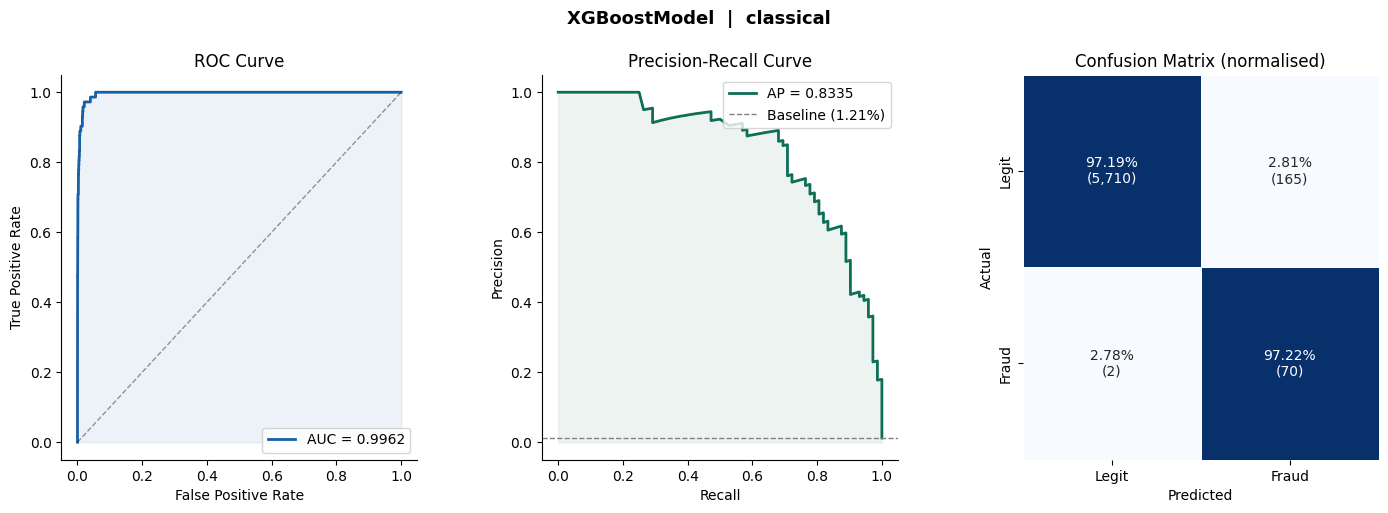

In [11]:
# ── Restart tip ──────────────────────────────────────────────────────────────
# If you see stale errors, do: Kernel → Restart & Run All
# Every class (ModelOutput, BaseModel, ..., ExperimentPipeline) must be
# defined in the same kernel session before this cell runs.
# ─────────────────────────────────────────────────────────────────────────────

processor = BankSimDataProcessor(
    csv_paths    = found_paths,
    use_smote    = USE_SMOTE,
    sample_frac  = SAMPLE_FRAC,
    random_state = 42,
)

evaluator = MetricsEvaluator()

MODEL_REGISTRY = {
    "XGBoostModel": lambda: XGBoostModel(
        use_gpu      = True,
        tune         = TUNE,
        n_trials     = N_TRIALS,
        n_estimators = N_ESTIMATORS,
        random_state = 42,
    ),
}

pipeline = ExperimentPipeline(
    processor      = processor,
    evaluator      = evaluator,
    model_registry = MODEL_REGISTRY,
    save_plots     = SAVE_PLOTS,
    verbose        = True,
)

results = pipeline.run_classical()


### Metrics summary table

In [12]:
eval_inst = MetricsEvaluator()
rows = []
for output in results:
    m = eval_inst.evaluate(output)
    rows.append({
        "Model":       output.model_name,
        "Experiment":  output.experiment_tag,
        "ROC-AUC":     m["roc_auc"],
        "PR-AUC":      m["pr_auc"],
        "F1":          m["f1"],
        "Precision":   m["precision"],
        "Recall":      m["recall"],
        "Train (s)":   output.metadata.get("train_time_s", "—"),
        "Device":      output.metadata.get("device", "—"),
        "Tuned":       output.metadata.get("tuned", False),
    })

metrics_df = pd.DataFrame(rows)
print("\n── Metrics Summary ──")
print(metrics_df.to_string(index=False))
metrics_df



── Metrics Summary ──
       Model Experiment  ROC-AUC  PR-AUC    F1  Precision  Recall  Train (s) Device  Tuned
XGBoostModel  classical   0.9962  0.8335 0.456     0.2979  0.9722      1.134    cpu  False


,Model,Experiment,ROC-AUC,PR-AUC,F1,Precision,Recall,Train (s),Device,Tuned
0,XGBoostModel,classical,0.9962,0.8335,0.456,0.2979,0.9722,1.134,cpu,False


### SHAP feature importance

Uses a 500-row sample of the test set for speed.  
Requires `shap` to be installed and the model to have fitted a `TreeExplainer`.


/tmp/ipykernel_9098/1417943070.py:109: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_sample, show=False, max_display=20)


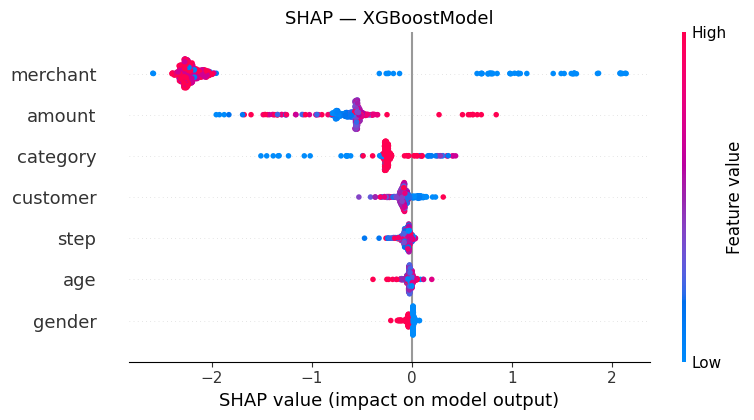

In [13]:
if results:
    first_output = results[0]
    model_ref    = first_output.metadata.get("_model_ref")
    if model_ref and hasattr(model_ref, "get_shap_values"):
        X_sample = pipeline._X_test.iloc[:500]
        eval_inst.plot_shap(model_ref, X_sample)
    else:
        print("Model reference not available for SHAP.")
else:
    print("No results yet — run pipeline.run_classical() first.")


## Cell 11 — `LightGBMModel` (Concrete Classifier)

Implements `BaseModel` using LightGBM — a gradient boosting framework
that uses **leaf-wise tree growth** instead of level-wise, making it
significantly faster than XGBoost on large datasets while matching or
exceeding its accuracy on tabular fraud data.

### Why LightGBM for fraud detection?

| Advantage | Relevance |
|---|---|
| Leaf-wise splitting | Finds complex fraud patterns faster per tree |
| Native `is_unbalance=True` | Handles 1.2% fraud rate without manual class weighting |
| Histogram-based algorithm | Trains on 594k rows in seconds on CPU |
| Built-in early stopping | Stops automatically when validation AUC plateaus |
| Optuna integration | Same TPE Bayesian search as XGBoostModel |

### Private method map (mirrors XGBoostModel structure)

| Method | Responsibility |
|---|---|
| `_build_params()` | Merge defaults with caller overrides and device config |
| `_maybe_split_val()` | Auto-carve 10% val set when `tune=True` but none given |
| `_run_optuna_study()` | Optuna TPE search over the LightGBM parameter space |
| `_build_dataset()` | Wrap DataFrames in `lgb.Dataset` with `free_raw_data` |
| `_fit_booster()` | Call `lgb.train()` with callbacks and timing |
| `_build_shap_explainer()` | Attach `shap.TreeExplainer` after fitting |
| `_build_metadata()` | Collect diagnostics for `ModelOutput.metadata` |


In [14]:
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split as _tts3

try:
    import lightgbm as lgb
    _LGB_OK = True
except ImportError:
    _LGB_OK = False
    warnings.warn('lightgbm not installed. pip install lightgbm>=4.0')

try:
    import optuna as _optuna_lgb
    _optuna_lgb.logging.set_verbosity(_optuna_lgb.logging.WARNING)
    _OPTUNA_LGB = True
except ImportError:
    _OPTUNA_LGB = False

try:
    import shap as _shap_lgb
    _SHAP_LGB = True
except ImportError:
    _SHAP_LGB = False


_LGB_DEFAULTS: Dict[str, Any] = {
    "n_estimators":      400,
    "max_depth":         -1,       # -1 = unlimited; leaf-wise growth controls depth
    "num_leaves":        63,
    "learning_rate":     0.05,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "min_child_samples": 20,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "is_unbalance":      True,     # native class-imbalance handling
    "verbosity":         -1,       # silence all LightGBM output
    "n_jobs":            -1,
}


class LightGBMModel(BaseModel):
    """
    LightGBM classifier satisfying the BaseModel contract.

    Uses leaf-wise tree growth and the native is_unbalance flag
    to handle BankSim class imbalance without external class weighting.

    Parameters
    ----------
    use_gpu      : use GPU device (requires LightGBM compiled with GPU support)
    tune         : run Optuna TPE search before final training
    n_trials     : number of Optuna trials (ignored when tune=False)
    random_state : master seed
    **overrides  : any lgb.train() parameter to override the defaults
    """

    def __init__(
        self,
        use_gpu:      bool = False,
        tune:         bool = False,
        n_trials:     int  = 50,
        random_state: int  = 42,
        **overrides: Any,
    ) -> None:
        super().__init__(random_state=random_state)
        if not _LGB_OK:
            raise ImportError('lightgbm not installed. pip install lightgbm>=4.0')
        self.use_gpu          = use_gpu
        self.tune             = tune
        self.n_trials         = n_trials
        self._device          = "gpu" if use_gpu else "cpu"
        self._best_params     = self._build_params(overrides)
        self._booster:          Optional[lgb.Booster] = None
        self._explainer:        Optional[Any]         = None
        self._train_time_s:     float                 = 0.0
        self._best_iteration:   Optional[int]         = None

    # ── BaseModel interface ───────────────────────────────────────────

    def train(self, X_train, y_train, X_val=None, y_val=None) -> None:
        """Orchestrate training via focused private steps."""
        self._log(
            f"device={self._device} | n={len(X_train):,} | "
            f"fraud={y_train.mean():.2%}"
        )
        X_val, y_val = self._maybe_split_val(X_train, y_train, X_val, y_val)
        if self.tune:
            self._best_params = self._run_optuna_study(X_train, y_train, X_val, y_val)
        self._fit_booster(X_train, y_train, X_val, y_val)
        self._build_shap_explainer(X_train)

    def predict(self, X_test, y_test, feature_names=None) -> ModelOutput:
        """Threshold=0.5 hard predictions + continuous probabilities."""
        self._assert_fitted()
        y_proba: np.ndarray = self._booster.predict(
            X_test, num_iteration=self._best_iteration
        )
        y_pred: np.ndarray = (y_proba >= 0.5).astype(int)
        return ModelOutput(
            y_true         = y_test.to_numpy(),
            y_pred         = y_pred,
            y_proba        = y_proba,
            model_name     = self.name,
            experiment_tag = "classical",
            metadata       = self._build_metadata(),
            feature_names  = feature_names or list(X_test.columns),
        )

    # ── Private step 1: build parameter dict ──────────────────────────

    def _build_params(self, overrides: Dict) -> Dict[str, Any]:
        """Merge defaults with caller overrides and device config."""
        return {
            **_LGB_DEFAULTS,
            "random_state": self.random_state,
            "seed":         self.random_state,
            "device":       self._device,
            **overrides,
        }

    # ── Private step 2: optional validation split ──────────────────────

    def _maybe_split_val(self, X_tr, y_tr, X_val, y_val):
        """Auto-carve 10% val when tune=True but none provided."""
        if self.tune and (X_val is None or y_val is None):
            self._log("tune=True, auto-splitting 10% val from train.")
            _, X_val, _, y_val = _tts3(
                X_tr, y_tr, test_size=0.1,
                stratify=y_tr, random_state=self.random_state,
            )
        return X_val, y_val

    # ── Private step 3: Optuna search ─────────────────────────────────

    def _run_optuna_study(self, X_tr, y_tr, X_val, y_val) -> Dict:
        """TPE Bayesian search over the LightGBM parameter space."""
        if not _OPTUNA_LGB:
            warnings.warn("optuna not installed — skipping tune.")
            return self._best_params
        self._log(f"Optuna: {self.n_trials} trials...")

        def objective(trial):
            p = {
                "num_leaves":       trial.suggest_int("num_leaves",       20, 300),
                "max_depth":        trial.suggest_int("max_depth",        3, 12),
                "learning_rate":    trial.suggest_float("learning_rate",  1e-3, 0.3, log=True),
                "subsample":        trial.suggest_float("subsample",      0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
                "min_child_samples":trial.suggest_int("min_child_samples", 5, 100),
                "reg_alpha":        trial.suggest_float("reg_alpha",      1e-4, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda",     1e-4, 10.0, log=True),
                "is_unbalance": True, "verbosity": -1, "n_jobs": -1,
                "random_state": self.random_state, "seed": self.random_state,
                "device": self._device,
            }
            n_est  = trial.suggest_int("n_estimators", 100, 800, step=50)
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            bst = lgb.train(p, dtrain, num_boost_round=n_est,
                            valid_sets=[dval],
                            callbacks=[lgb.early_stopping(20, verbose=False),
                                       lgb.log_evaluation(-1)])
            return roc_auc_score(y_val, bst.predict(X_val))

        study = _optuna_lgb.create_study(
            direction="maximize",
            sampler=_optuna_lgb.samplers.TPESampler(seed=self.random_state),
            pruner=_optuna_lgb.pruners.MedianPruner(n_startup_trials=5),
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=False)
        self._log(f"Optuna best ROC-AUC={study.best_value:.4f}")
        return {
            **study.best_params,
            "is_unbalance": True, "verbosity": -1, "n_jobs": -1,
            "random_state": self.random_state, "seed": self.random_state,
            "device": self._device,
        }

    # ── Private step 4: build lgb.Dataset ─────────────────────────────

    @staticmethod
    def _build_dataset(X, y, reference=None):
        """Wrap DataFrame/Series into lgb.Dataset with free_raw_data."""
        return lgb.Dataset(X, label=y, reference=reference, free_raw_data=True)

    # ── Private step 5: fit the booster ───────────────────────────────

    def _fit_booster(self, X_tr, y_tr, X_val, y_val) -> None:
        """Call lgb.train() with optional early stopping and timing."""
        params = dict(self._best_params)
        n_est  = int(params.pop("n_estimators", 400))
        dtrain = self._build_dataset(X_tr, y_tr)

        valid_sets  = [dtrain]
        valid_names = ["train"]
        callbacks   = [lgb.log_evaluation(-1)]

        if X_val is not None and y_val is not None:
            dval = self._build_dataset(X_val, y_val, reference=dtrain)
            valid_sets  = [dtrain, dval]
            valid_names = ["train", "valid"]
            callbacks.append(lgb.early_stopping(
                stopping_rounds=30, first_metric_only=True, verbose=False,
            ))

        t0 = time.perf_counter()
        self._booster = lgb.train(
            params, dtrain,
            num_boost_round=n_est,
            valid_sets=valid_sets,
            valid_names=valid_names,
            callbacks=callbacks,
        )
        self._train_time_s   = time.perf_counter() - t0
        self._best_iteration = self._booster.best_iteration or n_est
        self._is_fitted      = True
        self._log(
            f"Fit done in {self._train_time_s:.1f}s | "
            f"best_iteration={self._best_iteration}"
        )

    # ── Private step 6: SHAP explainer ────────────────────────────────

    def _build_shap_explainer(self, X_sample) -> None:
        if _SHAP_LGB:
            self._explainer = _shap_lgb.TreeExplainer(self._booster)
            self._log("SHAP TreeExplainer attached.")

    # ── Private step 7: metadata ───────────────────────────────────────

    def _build_metadata(self) -> Dict:
        return {
            "train_time_s":   round(self._train_time_s, 3),
            "device":         self._device,
            "best_iteration": self._best_iteration,
            "best_params":    self._best_params,
            "tuned":          self.tune,
        }

    @staticmethod
    def _log(msg: str) -> None:
        print(f"[LightGBMModel] {msg}")

    def get_shap_values(self, X):
        """Return fraud-class SHAP values. Called by MetricsEvaluator."""
        if not self._is_fitted or self._explainer is None:
            return None
        vals = self._explainer.shap_values(X)
        return vals[1] if isinstance(vals, list) else vals

    def save(self, path: str) -> None:
        self._assert_fitted()
        self._booster.save_model(path)
        self._log(f"Saved → {path}")

    def load(self, path: str) -> None:
        self._booster        = lgb.Booster(model_file=path)
        self._best_iteration = self._booster.best_iteration or None
        self._is_fitted      = True
        self._log(f"Loaded ← {path}")

    def __repr__(self) -> str:
        return (
            f"LightGBMModel(device={self._device}, "
            f"tune={self.tune}, fitted={self._is_fitted})"
        )


print("LightGBMModel ✓")


LightGBMModel ✓


## Cell 12 — XGBoost vs LightGBM Comparison

Runs **both models** on the **exact same data split** produced by Cell 10,
then produces:

1. A side-by-side **metrics table** (ROC-AUC, PR-AUC, F1, Precision, Recall,
   training time, device)
2. A **winner per metric** summary line showing which model wins and by how much
3. **Overlaid ROC and PR curves** with fill, legend, and baseline

The `processor` and `evaluator` from Cell 10 are reused directly —
no CSV re-read and no re-encoding. Only the `MODEL_REGISTRY` changes.



  DATA PREPARATION
[BankSimDataProcessor] Loading bs140513_032310.csv ...
[BankSimDataProcessor]   Raw columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']
[BankSimDataProcessor]   594,643 rows | fraud distribution: {0: 587443, 1: 7200}
[BankSimDataProcessor] Merged 1 file(s): 594,643 rows | fraud: 7,200 (1.211%)
[BankSimDataProcessor] Sub-sampled: 29,732 rows | fraud: 360 | fraud col present: True
[BankSimDataProcessor] Dropped noise columns: ['zipcodeOri', 'zipMerchant']
[BankSimDataProcessor] Freq-encoded "customer" (4,022 unique values)
[BankSimDataProcessor] Freq-encoded "merchant" (49 unique values)
[BankSimDataProcessor] Label-encoded "category" (15 classes)
[BankSimDataProcessor] Label-encoded "gender" (4 classes)
[BankSimDataProcessor] Label separated - 7 features | fraud: 360/29,732 (1.211%)
[BankSimDataProcessor] process() done - X: (29732, 7) | fraud: 1.211%
[BankSimDataProcessor] Split: train=23,785 | test=

/tmp/ipykernel_9098/1417943070.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


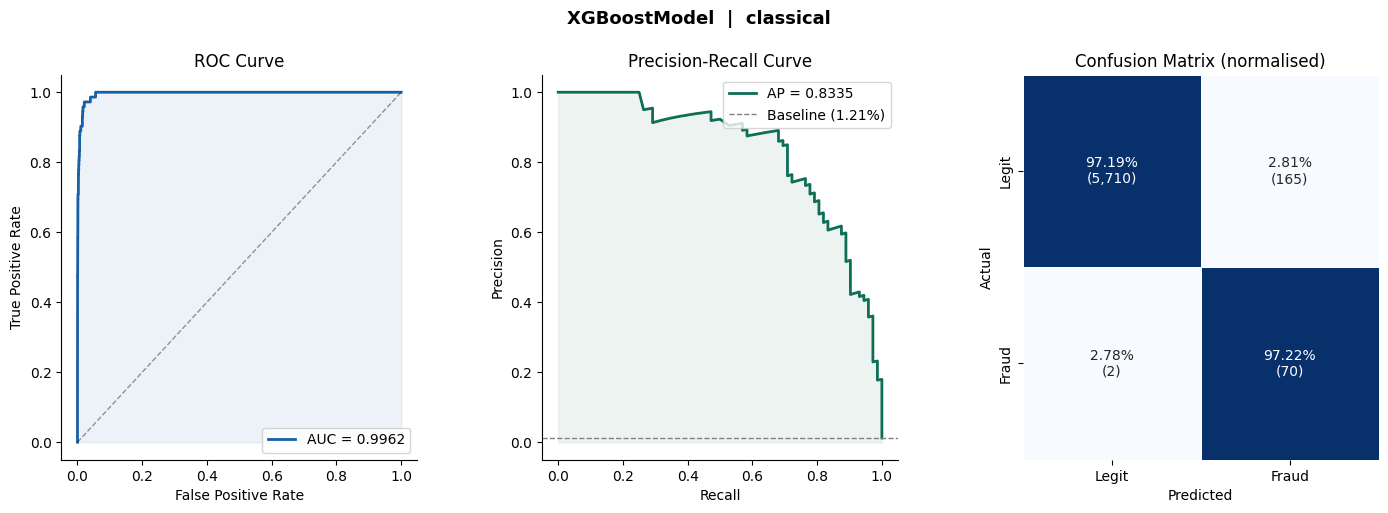


  [LightGBMModel] Training...
[LightGBMModel] device=cpu | n=23,785 | fraud=1.21%
[LightGBMModel] Fit done in 1.2s | best_iteration=50
[LightGBMModel] SHAP TreeExplainer attached.
──────────────────────────────────────────────
  Model          : LightGBMModel
  Experiment     : classical
──────────────────────────────────────────────
  ROC-AUC        : 0.9834
  PR-AUC         : 0.8719
  F1 Score       : 0.7581
  Precision      : 0.9038
  Recall         : 0.6528
──────────────────────────────────────────────
  Samples        : 5,947
  Fraud rate     : 1.21%
  Train time     : 1.2s
  Device         : cpu
  Optuna-tuned   : False
──────────────────────────────────────────────


/tmp/ipykernel_9098/1417943070.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


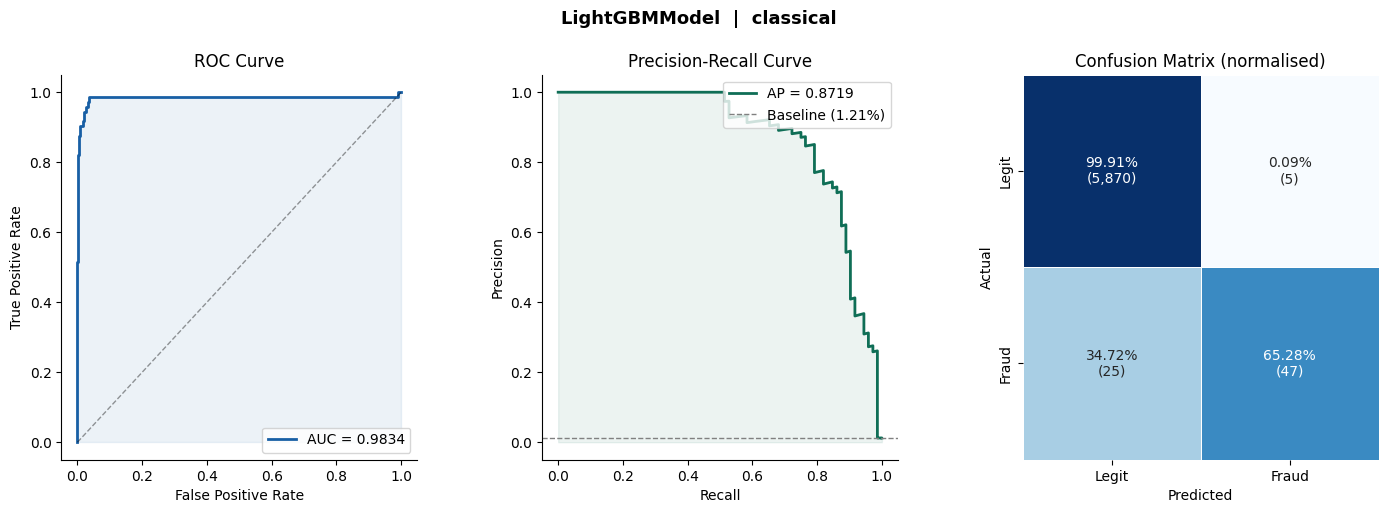


── Comparison Metrics ─────────────────────────────────────────────
               ROC-AUC  PR-AUC      F1  Precision  Recall  Train (s) Device
Model                                                                      
XGBoostModel    0.9962  0.8335  0.4560     0.2979  0.9722      0.594    cpu
LightGBMModel   0.9834  0.8719  0.7581     0.9038  0.6528      1.247    cpu

  ROC-AUC       winner: XGBoostModel        delta: +0.0128
  PR-AUC        winner: LightGBMModel       delta: +0.0384
  F1            winner: LightGBMModel       delta: +0.3021
  Precision     winner: LightGBMModel       delta: +0.6059
  Recall        winner: XGBoostModel        delta: +0.3194


/tmp/ipykernel_9098/2536026622.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


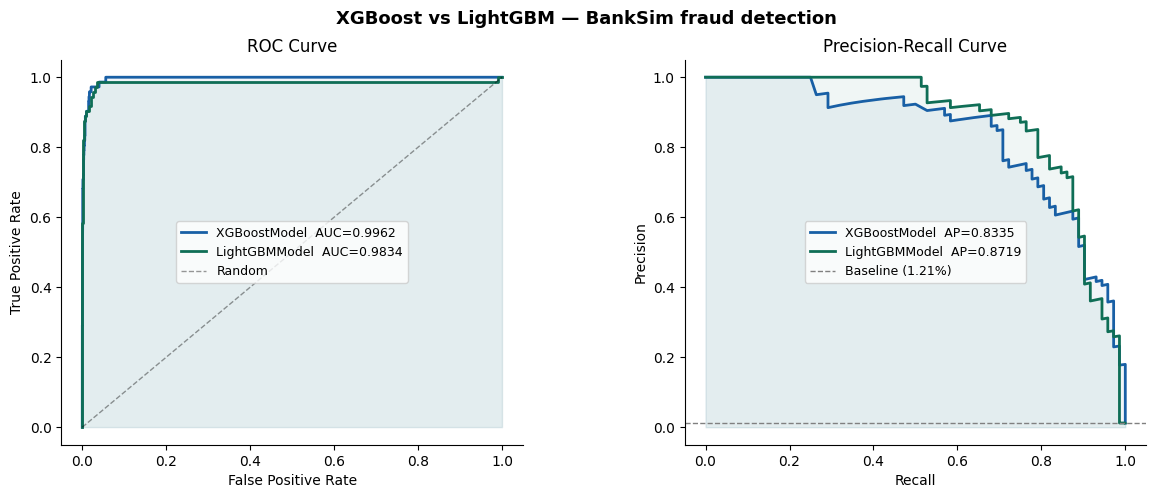

,ROC-AUC,PR-AUC,F1,Precision,Recall,Train (s),Device
Model,,,,,,,
XGBoostModel,0.9962,0.8335,0.4560,0.2979,0.9722,0.594,cpu
LightGBMModel,0.9834,0.8719,0.7581,0.9038,0.6528,1.247,cpu


In [ ]:
# ── Both models use the data already prepared in Cell 10 ─────────────────
# processor, evaluator, found_paths, TUNE, N_TRIALS, N_ESTIMATORS,
# SAVE_PLOTS are all defined there and still in scope.

COMPARE_REGISTRY = {
    "XGBoostModel": lambda: XGBoostModel(
        use_gpu      = True,
        tune         = TUNE,
        n_trials     = N_TRIALS,
        n_estimators = N_ESTIMATORS,
        random_state = 42,
    ),
    "LightGBMModel": lambda: LightGBMModel(
        use_gpu      = False,   # set True only if lgb GPU build is available
        tune         = TUNE,
        n_trials     = N_TRIALS,
        n_estimators = N_ESTIMATORS,
        random_state = 42,
    ),
}

# Build a fresh pipeline that reuses processor (no re-read of CSV)
compare_pipeline = ExperimentPipeline(
    processor      = processor,
    evaluator      = evaluator,
    model_registry = COMPARE_REGISTRY,
    save_plots     = SAVE_PLOTS,
    verbose        = True,
)

compare_results = compare_pipeline.run_classical()

# ── Side-by-side metrics table ────────────────────────────────────────────
import pandas as pd

_eval = MetricsEvaluator()
rows = []
for out in compare_results:
    m = _eval.evaluate(out)
    rows.append({
        "Model":      out.model_name,
        "ROC-AUC":    m["roc_auc"],
        "PR-AUC":     m["pr_auc"],
        "F1":         m["f1"],
        "Precision":  m["precision"],
        "Recall":     m["recall"],
        "Train (s)":  out.metadata.get("train_time_s", "---"),
        "Device":     out.metadata.get("device", "---"),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
print("\n── Comparison Metrics ─────────────────────────────────────────────")
print(metrics_df.to_string())
print()

# Winner per metric
for col in ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]:
    winner = metrics_df[col].idxmax()
    delta  = metrics_df[col].max() - metrics_df[col].min()
    print(f"  {col:12s}  winner: {winner:<18s}  delta: +{delta:.4f}")

# ── Overlaid ROC and PR curves ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

COLORS = {
    "XGBoostModel":  "#185FA5",
    "LightGBMModel": "#0F6E56",
}

fig = plt.figure(figsize=(14, 5))
fig.suptitle("XGBoost vs LightGBM — BankSim fraud detection",
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax_roc = fig.add_subplot(gs[0])
ax_pr  = fig.add_subplot(gs[1])

for out in compare_results:
    m     = _eval.evaluate(out)
    color = COLORS.get(out.model_name, "gray")

    fpr, tpr, _ = roc_curve(out.y_true, out.y_proba)
    ax_roc.plot(fpr, tpr, color=color, lw=2,
               label=f"{out.model_name}  AUC={m['roc_auc']:.4f}")
    ax_roc.fill_between(fpr, tpr, alpha=0.06, color=color)

    prec, rec, _ = precision_recall_curve(out.y_true, out.y_proba)
    ax_pr.plot(rec, prec, color=color, lw=2,
              label=f"{out.model_name}  AP={m['pr_auc']:.4f}")
    ax_pr.fill_between(rec, prec, alpha=0.06, color=color)

fraud_rate = compare_results[0].fraud_rate
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random")
ax_pr.axhline(fraud_rate, color="gray", lw=1, linestyle="--",
             label=f"Baseline ({fraud_rate:.2%})")

for ax, xl, yl, title in [
    (ax_roc, "False Positive Rate", "True Positive Rate", "ROC Curve"),
    (ax_pr,  "Recall",              "Precision",          "Precision-Recall Curve"),
]:
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

metrics_df


## Cell 13 — `MLPModel` (PyTorch Feed-Forward Network)

Implements `BaseModel` using a fully-connected feed-forward neural network
built with **PyTorch**. Unlike the tree-based models, the MLP learns
distributed representations and can capture feature-interaction patterns
that explicit splits cannot.

### Architecture

```
Input (7 features)
  ↓
Linear(7 → 128) + BatchNorm + ReLU + Dropout(0.3)
  ↓
Linear(128 → 64) + BatchNorm + ReLU + Dropout(0.3)
  ↓
Linear(64 → 32)  + BatchNorm + ReLU + Dropout(0.2)
  ↓
Linear(32 → 1)   → raw logit → Sigmoid → P(fraud)
```

### Design decisions for fraud detection

| Decision | Reason |
|---|---|
| `BCEWithLogitsLoss(pos_weight=n_neg/n_pos)` | Handles 1.2% fraud imbalance natively |
| `BatchNorm` after every linear layer | Stabilises training on scaled tabular features |
| `Dropout(0.3 / 0.2)` | Regularises against overfitting on the small fraud class |
| Early stopping on val PR-AUC | PR-AUC is the right stopping signal for imbalanced data |
| `ReduceLROnPlateau` scheduler | Halves LR when val PR-AUC plateaus for 3 epochs |
| `clip_grad_norm_(max=1.0)` | Prevents exploding gradients on deep layers |
| GPU auto-detection | Uses CUDA if available, falls back to CPU silently |
| Optuna integration | Same TPE interface as XGBoost and LightGBM |

### Private method map

| Method | Responsibility |
|---|---|
| `_resolve_device()` | Detect CUDA / CPU once at construction |
| `_build_network()` | Instantiate the `_FraudNet` `nn.Sequential` architecture |
| `_make_loader()` | Wrap DataFrames into `TensorDataset` + `DataLoader` |
| `_compute_pos_weight()` | Derive `n_neg / n_pos` for `BCEWithLogitsLoss` |
| `_run_optuna_study()` | Optuna TPE over hidden sizes, lr, dropout, batch size |
| `_run_epochs()` | Training loop with early stopping on val PR-AUC |
| `_fit_network()` | Calls `_run_epochs`, records timing, sets `_is_fitted` |
| `_build_metadata()` | Collect diagnostics for `ModelOutput.metadata` |


In [ ]:
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split as _tts4

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    _TORCH_OK = True
except ImportError:
    _TORCH_OK = False
    warnings.warn('torch not installed. pip install torch>=2.1')

try:
    import optuna as _optuna_mlp
    _optuna_mlp.logging.set_verbosity(_optuna_mlp.logging.WARNING)
    _OPTUNA_MLP = True
except ImportError:
    _OPTUNA_MLP = False


_MLP_DEFAULTS: Dict[str, Any] = {
    "hidden_sizes":  [128, 64, 32],
    "dropout_rates": [0.3, 0.3, 0.2],
    "learning_rate": 1e-3,
    "batch_size":    512,
    "max_epochs":    100,
    "patience":      10,
    "weight_decay":  1e-4,
}


class _FraudNet(nn.Module):
    """Feed-forward stack: Linear -> BatchNorm -> ReLU -> Dropout, repeated."""

    def __init__(self, n_features: int, hidden_sizes: List[int],
                 dropout_rates: List[float]) -> None:
        super().__init__()
        layers = []
        in_dim = n_features
        for h, d in zip(hidden_sizes, dropout_rates):
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(d)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class MLPModel(BaseModel):
    """
    PyTorch MLP classifier satisfying the BaseModel contract.

    Uses BCEWithLogitsLoss + pos_weight for class imbalance,
    BatchNorm for stability, Dropout for regularisation, and
    early stopping on validation PR-AUC.

    Parameters
    ----------
    use_gpu      : use CUDA if available (silent CPU fallback)
    tune         : run Optuna TPE search before final training
    n_trials     : number of Optuna trials (ignored when tune=False)
    random_state : master seed
    **overrides  : any key from _MLP_DEFAULTS to override
    """

    def __init__(self, use_gpu=True, tune=False, n_trials=20,
                 random_state=42, **overrides):
        super().__init__(random_state=random_state)
        if not _TORCH_OK:
            raise ImportError('torch not installed. pip install torch>=2.1')
        self.use_gpu          = use_gpu
        self.tune             = tune
        self.n_trials         = n_trials
        self._device          = self._resolve_device()
        self._hparams         = {**_MLP_DEFAULTS, **overrides}
        self._net             = None
        self._train_time_s    = 0.0
        self._best_epoch      = 0

    # ── BaseModel interface ───────────────────────────────────────────────

    def train(self, X_train, y_train, X_val=None, y_val=None):
        """Orchestrate training via focused private steps."""
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        self._log(
            f"device={self._device} | n={len(X_train):,} | "
            f"fraud={y_train.mean():.2%} | features={X_train.shape[1]}"
        )
        if X_val is None or y_val is None:
            X_train, X_val, y_train, y_val = _tts4(
                X_train, y_train, test_size=0.15,
                stratify=y_train, random_state=self.random_state)
        if self.tune:
            self._hparams = self._run_optuna_study(X_train, y_train, X_val, y_val)
        self._net = self._build_network(X_train.shape[1])
        self._fit_network(X_train, y_train, X_val, y_val)

    def predict(self, X_test, y_test, feature_names=None):
        """Sigmoid at inference; threshold = 0.5."""
        self._assert_fitted()
        self._net.eval()
        X_t = torch.tensor(X_test.values, dtype=torch.float32).to(self._device)
        with torch.no_grad():
            y_proba = torch.sigmoid(self._net(X_t)).cpu().numpy()
        y_pred = (y_proba >= 0.5).astype(int)
        return ModelOutput(
            y_true=y_test.to_numpy(), y_pred=y_pred, y_proba=y_proba,
            model_name=self.name, experiment_tag="classical",
            metadata=self._build_metadata(),
            feature_names=feature_names or list(X_test.columns),
        )

    # ── Private step 1: device ────────────────────────────────────────────

    def _resolve_device(self):
        if self.use_gpu and torch.cuda.is_available():
            self._log(f"CUDA available - {torch.cuda.get_device_name(0)}")
            return "cuda"
        return "cpu"

    # ── Private step 2: build network ─────────────────────────────────────

    def _build_network(self, n_features):
        """Instantiate _FraudNet and move to the target device."""
        return _FraudNet(
            n_features=n_features,
            hidden_sizes=self._hparams["hidden_sizes"],
            dropout_rates=self._hparams["dropout_rates"],
        ).to(self._device)

    # ── Private step 3: DataLoader ────────────────────────────────────────

    def _make_loader(self, X, y, batch_size, shuffle=True):
        """Wrap a DataFrame/Series pair into a DataLoader."""
        X_t = torch.tensor(X.values, dtype=torch.float32)
        y_t = torch.tensor(y.values.astype("float32"), dtype=torch.float32)
        return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size,
                          shuffle=shuffle, pin_memory=(self._device == "cuda"))

    # ── Private step 4: pos_weight ────────────────────────────────────────

    @staticmethod
    def _compute_pos_weight(y):
        """n_neg / n_pos — same role as scale_pos_weight in XGBoost."""
        n_neg, n_pos = int((y == 0).sum()), int((y == 1).sum())
        if n_pos == 0:
            raise ValueError('No fraud samples in training data.')
        return n_neg / n_pos

    # ── Private step 5: Optuna search ─────────────────────────────────────

    def _run_optuna_study(self, X_tr, y_tr, X_val, y_val):
        """TPE search over hidden sizes, lr, dropout, batch size."""
        if not _OPTUNA_MLP:
            warnings.warn('optuna not installed - skipping tune.')
            return self._hparams
        self._log(f"Optuna: {self.n_trials} trials...")

        def objective(trial):
            n_layers = trial.suggest_int('n_layers', 2, 4)
            hp = {
                'hidden_sizes':  [trial.suggest_int(f'h{i}', 32, 256, step=32)
                                  for i in range(n_layers)],
                'dropout_rates': [trial.suggest_float(f'd{i}', 0.1, 0.5)
                                  for i in range(n_layers)],
                'learning_rate': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
                'batch_size':    trial.suggest_categorical('bs', [256, 512, 1024]),
                'weight_decay':  trial.suggest_float('wd', 1e-5, 1e-3, log=True),
                'max_epochs': 30, 'patience': 5,
            }
            net = _FraudNet(X_tr.shape[1],
                            hp['hidden_sizes'], hp['dropout_rates']).to(self._device)
            _, pr_auc = self._run_epochs(net, X_tr, y_tr, X_val, y_val,
                                         hp, verbose=False)
            return pr_auc

        study = _optuna_mlp.create_study(
            direction='maximize',
            sampler=_optuna_mlp.samplers.TPESampler(seed=self.random_state),
            pruner=_optuna_mlp.pruners.MedianPruner(n_startup_trials=5),
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=False)
        self._log(f"Optuna best PR-AUC={study.best_value:.4f}")
        bp  = study.best_params
        n_l = bp.pop('n_layers')
        return {
            'hidden_sizes':  [bp.pop(f'h{i}') for i in range(n_l)],
            'dropout_rates': [bp.pop(f'd{i}') for i in range(n_l)],
            'learning_rate': bp.pop('lr'),
            'batch_size':    bp.pop('bs'),
            'weight_decay':  bp.pop('wd'),
            'max_epochs':    self._hparams['max_epochs'],
            'patience':      self._hparams['patience'],
        }

    # ── Private step 6: training loop ─────────────────────────────────────

    def _run_epochs(self, net, X_tr, y_tr, X_val, y_val, hp, verbose=True):
        """Epoch loop with early stopping on val PR-AUC.
        Returns (best_epoch, best_val_pr_auc).
        """
        pw = torch.tensor([self._compute_pos_weight(y_tr)],
                          dtype=torch.float32).to(self._device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
        optimizer = torch.optim.Adam(net.parameters(),
                                     lr=hp['learning_rate'],
                                     weight_decay=hp['weight_decay'])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3)
        train_loader = self._make_loader(X_tr,  y_tr,  hp['batch_size'])
        val_loader   = self._make_loader(X_val, y_val, hp['batch_size'], shuffle=False)

        best_pr, best_epoch, best_state, no_improve = 0.0, 0, None, 0

        for epoch in range(1, hp['max_epochs'] + 1):
            net.train()
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(self._device), yb.to(self._device)
                optimizer.zero_grad()
                loss = criterion(net(Xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), 1.0)
                optimizer.step()

            net.eval()
            probs, labels = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    probs.append(torch.sigmoid(
                        net(Xb.to(self._device))).cpu().numpy())
                    labels.append(yb.numpy())
            pr_auc = average_precision_score(
                np.concatenate(labels), np.concatenate(probs))
            scheduler.step(pr_auc)

            if pr_auc > best_pr:
                best_pr    = pr_auc
                best_epoch = epoch
                best_state = {k: v.clone() for k, v in net.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if verbose and epoch % 10 == 0:
                self._log(f"epoch {epoch:3d} | val PR-AUC={pr_auc:.4f} "
                          f"(best={best_pr:.4f} @ epoch {best_epoch})")

            if no_improve >= hp['patience']:
                if verbose:
                    self._log(f"Early stop @ epoch {epoch} | "
                              f"best PR-AUC={best_pr:.4f} @ epoch {best_epoch}")
                break

        if best_state:
            net.load_state_dict(best_state)
        return best_epoch, best_pr

    def _fit_network(self, X_tr, y_tr, X_val, y_val):
        """Full training run; sets _is_fitted=True."""
        t0 = time.perf_counter()
        self._best_epoch, best_pr = self._run_epochs(
            self._net, X_tr, y_tr, X_val, y_val, self._hparams, verbose=True)
        self._train_time_s = time.perf_counter() - t0
        self._is_fitted    = True
        self._log(f"Done in {self._train_time_s:.1f}s | "
                  f"best_epoch={self._best_epoch} | val PR-AUC={best_pr:.4f}")

    # ── Private step 7: metadata ──────────────────────────────────────────

    def _build_metadata(self):
        return {
            "train_time_s": round(self._train_time_s, 3),
            "device":       self._device,
            "best_epoch":   self._best_epoch,
            "hparams":      self._hparams,
            "tuned":        self.tune,
        }

    @staticmethod
    def _log(msg):
        print(f"[MLPModel] {msg}")

    def __repr__(self):
        return (f"MLPModel(device={self._device}, "
                f"tune={self.tune}, fitted={self._is_fitted})")


print("MLPModel ✓")


## Cell 14 — XGBoost vs LightGBM vs MLP — Three-Way Comparison

Runs all three models on the **same data split** from Cell 10.
No CSV re-read — `processor` and `evaluator` are reused directly.

Produces:

1. Full **metrics table** — ROC-AUC, PR-AUC, F1, Precision, Recall, train time, device
2. **Winner per metric** with delta vs second place
3. **Overlaid ROC and PR curves** for all three models on the same axes


In [ ]:
# All three models reuse the data prepared in Cell 10.
# processor, evaluator, TUNE, N_TRIALS, N_ESTIMATORS, SAVE_PLOTS in scope.

THREE_REGISTRY = {
    "XGBoostModel": lambda: XGBoostModel(
        use_gpu=True,  tune=TUNE, n_trials=N_TRIALS,
        n_estimators=N_ESTIMATORS, random_state=42,
    ),
    "LightGBMModel": lambda: LightGBMModel(
        use_gpu=False, tune=TUNE, n_trials=N_TRIALS,
        n_estimators=N_ESTIMATORS, random_state=42,
    ),
    "MLPModel": lambda: MLPModel(
        use_gpu=True,  tune=TUNE, n_trials=N_TRIALS, random_state=42,
    ),
}

three_pipeline = ExperimentPipeline(
    processor=processor, evaluator=evaluator,
    model_registry=THREE_REGISTRY, save_plots=SAVE_PLOTS, verbose=True,
)
three_results = three_pipeline.run_classical()

# ── Metrics table ─────────────────────────────────────────────────────────────
import pandas as pd

_eval3 = MetricsEvaluator()
rows3  = []
for out in three_results:
    m = _eval3.evaluate(out)
    rows3.append({
        "Model":      out.model_name,
        "ROC-AUC":    m["roc_auc"],
        "PR-AUC":     m["pr_auc"],
        "F1":         m["f1"],
        "Precision":  m["precision"],
        "Recall":     m["recall"],
        "Train (s)":  out.metadata.get("train_time_s", "---"),
        "Device":     out.metadata.get("device", "---"),
    })

three_df = pd.DataFrame(rows3).set_index("Model")
print("\n-- Three-Model Comparison " + "-" * 34)
print(three_df.to_string())
print()

# Winner per metric
for col in ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]:
    winner = three_df[col].idxmax()
    delta  = three_df[col].max() - three_df[col].min()
    print(f"  {col:12s}  winner: {winner:<18s}  delta: +{delta:.4f}")

# ── Overlaid ROC and PR curves ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

COLORS3 = {
    "XGBoostModel":  "#185FA5",
    "LightGBMModel": "#0F6E56",
    "MLPModel":      "#993C1D",
}

fig = plt.figure(figsize=(14, 5))
fig.suptitle("XGBoost vs LightGBM vs MLP — BankSim fraud detection",
             fontsize=13, fontweight='bold')
gs     = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax_roc = fig.add_subplot(gs[0])
ax_pr  = fig.add_subplot(gs[1])

for out in three_results:
    m     = _eval3.evaluate(out)
    color = COLORS3.get(out.model_name, "gray")

    fpr, tpr, _ = roc_curve(out.y_true, out.y_proba)
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"{out.model_name}  AUC={m['roc_auc']:.4f}")
    ax_roc.fill_between(fpr, tpr, alpha=0.06, color=color)

    prec, rec, _ = precision_recall_curve(out.y_true, out.y_proba)
    ax_pr.plot(rec, prec, color=color, lw=2,
               label=f"{out.model_name}  AP={m['pr_auc']:.4f}")
    ax_pr.fill_between(rec, prec, alpha=0.06, color=color)

fraud_rate3 = three_results[0].fraud_rate
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
ax_pr.axhline(fraud_rate3, color='gray', lw=1, linestyle='--',
              label=f'Baseline ({fraud_rate3:.2%})')

for ax, xl, yl, title in [
    (ax_roc, 'False Positive Rate', 'True Positive Rate', 'ROC Curve'),
    (ax_pr,  'Recall',              'Precision',          'Precision-Recall Curve'),
]:
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

three_df
